In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score

VOG_CSV = Path("/home/student/lisa_ma/results/vog/20260925_021333/vog_scores_20260925_021333.csv")
RC_XLSX = Path("/home/student/lisa_ma/evaluation/gt_mislabels_complete.xlsx")

scores_df = pd.read_csv(VOG_CSV)
scores_df["vog_score"] = pd.to_numeric(scores_df["vog_score"], errors="coerce")
scores_df = scores_df.dropna(subset=["vog_score"]).reset_index(drop=True)

df_rc     = pd.read_excel(RC_XLSX)
positives = set(df_rc["sample_id"].astype(str))
scores_df["mislabeled"] = scores_df["id"].apply(lambda x: 1 if x in positives else 0)

In [2]:
n_total     = len(scores_df)
n_mislabels = scores_df["mislabeled"].sum()
base_rate   = scores_df["mislabeled"].mean()

y_true  = scores_df["mislabeled"].values
y_score = scores_df["vog_score"].values   # higher = more suspicious

auroc = roc_auc_score(y_true, y_score)
ap    = average_precision_score(y_true, y_score)

rows = []
for frac in [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.50, 1.0]:
    k         = max(1, int(np.ceil(frac * n_total)))
    threshold = np.sort(y_score)[::-1][k - 1]
    y_pred    = (y_score >= threshold).astype(int)
    actual_frac = y_pred.sum() / n_total
    recall    = recall_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    rows.append({"fraction": actual_frac, "recall": recall, "precision": precision, "f1": f1})

detail_df = pd.DataFrame(rows)
best      = detail_df.loc[detail_df["f1"].idxmax()]

print("=" * 52)
print("  VoG Run Summary — VerSe Sep 25, 2026")
print("=" * 52)
print(f"  Training samples:              {n_total:,}")
print(f"  Confirmed mislabels:           {n_mislabels}")
print(f"  Base mislabel rate:            {base_rate:.2%}")
print(f"  t_window:                      5 epochs")
print()
print("  Detection Performance")
print("  " + "-" * 38)
print(f"  AUROC:                         {auroc:.4f}")
print(f"  Average Precision:             {ap:.4f}")
print(f"  Best F1:                       {best.f1:.4f}")
print(f"    Recall at best F1:           {best.recall:.2%}")
print(f"    Precision at best F1:        {best.precision:.2%}")
print(f"    Fraction checked:            {best.fraction:.2%}")
print("=" * 52)
print()
print("  Fraction-threshold table:")
print(detail_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

  VoG Run Summary — VerSe Sep 25, 2026
  Training samples:              19,266
  Confirmed mislabels:           107
  Base mislabel rate:            0.56%
  t_window:                      5 epochs

  Detection Performance
  --------------------------------------
  AUROC:                         0.8643
  Average Precision:             0.0517
  Best F1:                       0.1067
    Recall at best F1:           14.95%
    Precision at best F1:        8.29%
    Fraction checked:            1.00%

  Fraction-threshold table:
 fraction  recall  precision     f1
   0.0010  0.0093     0.0500 0.0157
   0.0020  0.0467     0.1282 0.0685
   0.0050  0.0935     0.1031 0.0980
   0.0100  0.1495     0.0829 0.1067
   0.0200  0.2150     0.0596 0.0933
   0.0500  0.4673     0.0519 0.0934
   0.1000  0.6075     0.0337 0.0639
   0.2000  0.8037     0.0223 0.0434
   0.5000  0.9439     0.0105 0.0207
   1.0000  1.0000     0.0056 0.0110


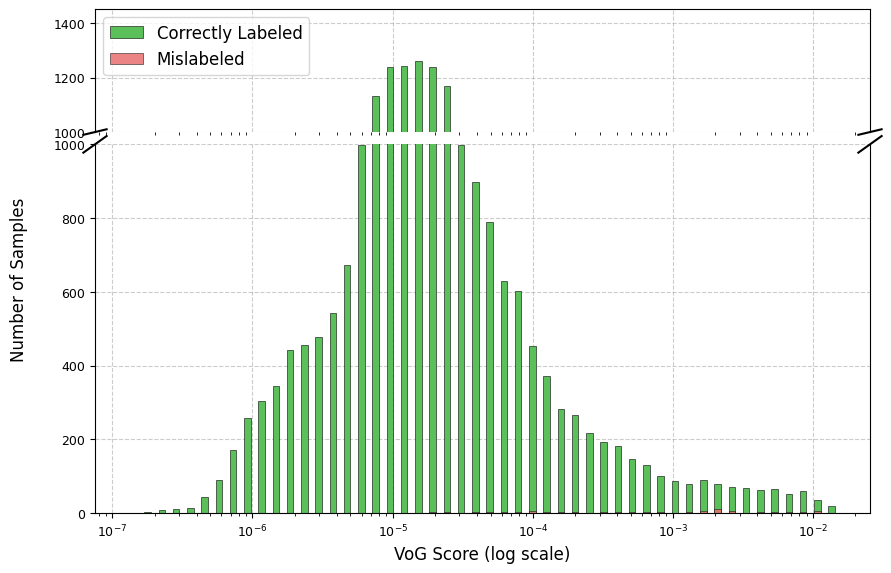

In [3]:
# Score distribution histogram (log-scale x-axis, broken y-axis)
log_bins = np.logspace(
    np.log10(scores_df["vog_score"].min()),
    np.log10(scores_df["vog_score"].max()),
    51
)

clean_vals    = scores_df.loc[scores_df["mislabeled"] == 0, "vog_score"].values
mislabel_vals = scores_df.loc[scores_df["mislabeled"] == 1, "vog_score"].values

clean_counts,    _ = np.histogram(clean_vals,    bins=log_bins)
mislabel_counts, _ = np.histogram(mislabel_vals, bins=log_bins)
bin_widths         = np.diff(log_bins)
bin_centers        = np.sqrt(log_bins[:-1] * log_bins[1:])

lower_ylim = 1000
top_ylim   = int(np.ceil(clean_counts.max() * 1.15))

fig = plt.figure(figsize=(10, 6))
gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.05)
ax_top    = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[1], sharex=ax_top)

for ax in (ax_top, ax_bottom):
    ax.bar(bin_centers, clean_counts,    width=bin_widths * 0.45, align="center",
           color="#5BBF5A", edgecolor="black", linewidth=0.4, label="Correctly Labeled")
    ax.bar(bin_centers, mislabel_counts, width=bin_widths * 0.45, align="center",
           color="#E87070", edgecolor="black", linewidth=0.4, label="Mislabeled", alpha=0.85)
    ax.set_facecolor("white")
    ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
    ax.set_axisbelow(True)
    ax.set_xscale("log")

ax_top.set_ylim(lower_ylim, top_ylim)
ax_bottom.set_ylim(0, lower_ylim)
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False, labelbottom=False)

d = 0.015
for ax, y_vals in [(ax_top, (-d*1.5, +d*1.5)), (ax_bottom, (1-d*1.5, 1+d*1.5))]:
    kw = dict(transform=ax.transAxes, color="k", clip_on=False)
    ax.plot((-d, +d),   y_vals, **kw)
    ax.plot((1-d, 1+d), y_vals, **kw)

ax_bottom.set_xlabel("VoG Score (log scale)", fontsize=12)
ax_top.tick_params(axis="both", labelsize=9)
ax_bottom.tick_params(axis="both", labelsize=9)
ax_top.legend(fontsize=12, frameon=True, loc="upper left")
fig.supylabel("Number of Samples", fontsize=12, x=0.04)
fig.subplots_adjust(top=0.95)
plt.savefig("/home/student/lisa_ma/figures/histogram_all_vog.jpg", dpi=300, bbox_inches="tight")
plt.show()

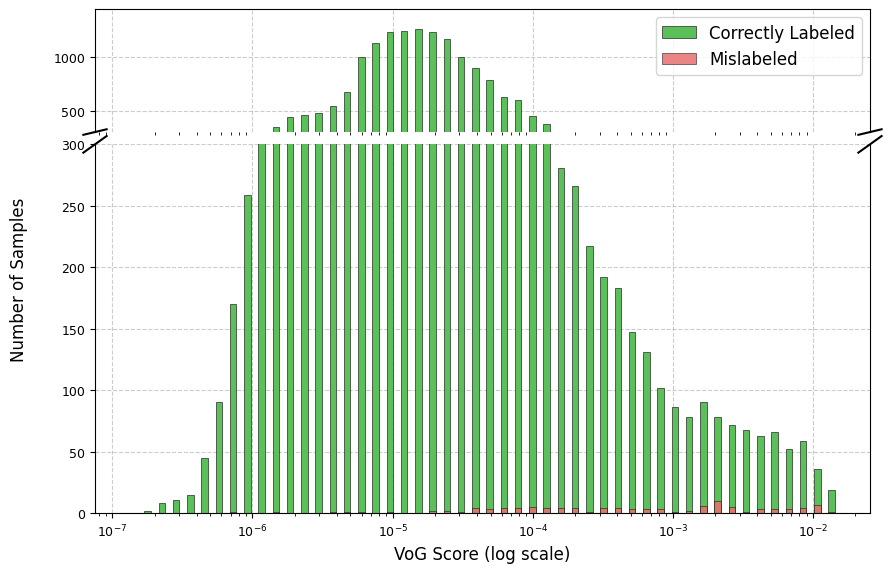

In [4]:
# Score distribution histogram (zoomed, lower_ylim=300)
lower_ylim_z = 300

fig = plt.figure(figsize=(10, 6))
gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.05)
ax_top    = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[1], sharex=ax_top)

for ax in (ax_top, ax_bottom):
    ax.bar(bin_centers, clean_counts,    width=bin_widths * 0.45, align="center",
           color="#5BBF5A", edgecolor="black", linewidth=0.4, label="Correctly Labeled")
    ax.bar(bin_centers, mislabel_counts, width=bin_widths * 0.45, align="center",
           color="#E87070", edgecolor="black", linewidth=0.4, label="Mislabeled", alpha=0.85)
    ax.set_facecolor("white")
    ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
    ax.set_axisbelow(True)
    ax.set_xscale("log")

ax_top.set_ylim(lower_ylim_z, top_ylim)
ax_bottom.set_ylim(0, lower_ylim_z)
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False, labelbottom=False)

d = 0.015
for ax, y_vals in [(ax_top, (-d*1.5, +d*1.5)), (ax_bottom, (1-d*1.5, 1+d*1.5))]:
    kw = dict(transform=ax.transAxes, color="k", clip_on=False)
    ax.plot((-d, +d),   y_vals, **kw)
    ax.plot((1-d, 1+d), y_vals, **kw)

ax_bottom.set_xlabel("VoG Score (log scale)", fontsize=12)
ax_top.tick_params(axis="both", labelsize=9)
ax_bottom.tick_params(axis="both", labelsize=9)
ax_top.legend(fontsize=12, frameon=True, loc="upper right")
fig.supylabel("Number of Samples", fontsize=12, x=0.04)
fig.subplots_adjust(top=0.95)
plt.savefig("/home/student/lisa_ma/figures/histogram_all_vog_zoom.jpg", dpi=300, bbox_inches="tight")
plt.show()

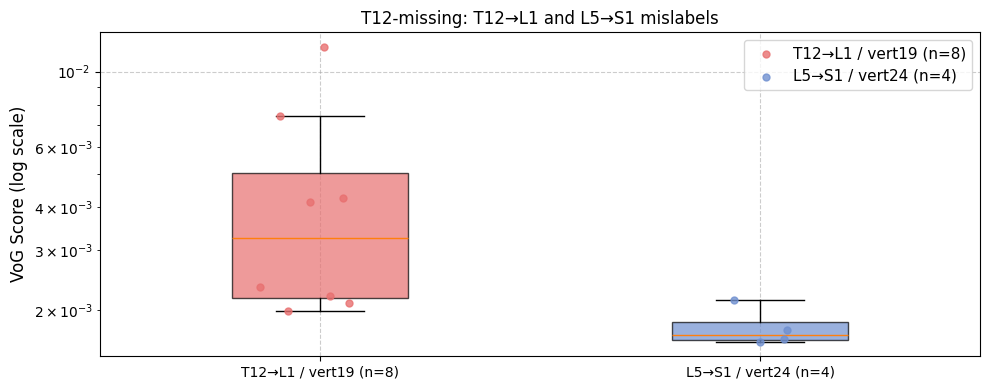

In [5]:
# T12-missing: T12→L1 (vert19) vs L5→S1 (vert24)
v19_ids = set(df_rc[(df_rc["anomaly_type"] == "T12_missing") & (df_rc["vert_id"] == 19)]["sample_id"].astype(str))
v24_ids = set(df_rc[(df_rc["anomaly_type"] == "T12_missing") & (df_rc["vert_id"] == 24)]["sample_id"].astype(str))

v19_df = scores_df[scores_df["id"].isin(v19_ids)]
v24_df = scores_df[scores_df["id"].isin(v24_ids)]

fig, ax = plt.subplots(figsize=(10, 4))
positions = [1, 2]
data      = [v19_df["vog_score"].values, v24_df["vog_score"].values]
labels    = [f"T12→L1 / vert19 (n={len(v19_df)})", f"L5→S1 / vert24 (n={len(v24_df)})"]
colors    = ["#E87070", "#7090D0"]

bp = ax.boxplot(data, positions=positions, widths=0.4, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

rng = np.random.default_rng(42)
for pos, vals, color, label in zip(positions, data, colors, labels):
    ax.scatter(rng.normal(pos, 0.07, size=len(vals)), vals,
               color=color, alpha=0.8, s=25, zorder=3, label=label)

ax.set_yscale("log")
ax.set_ylabel("VoG Score (log scale)", fontsize=12)
ax.set_title("T12-missing: T12→L1 and L5→S1 mislabels", fontsize=12)
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=10)
ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_facecolor("white")
ax.legend(fontsize=11, frameon=True)
plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/boxplot_T12missing_vog.pdf", dpi=300, bbox_inches="tight")
plt.show()

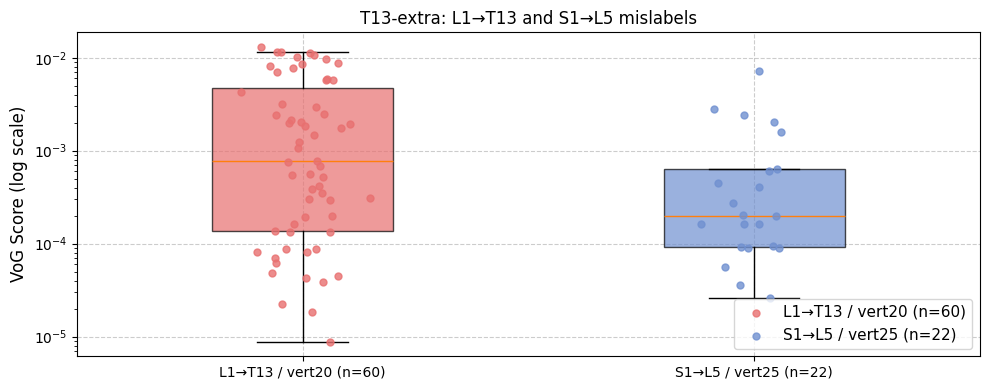

In [6]:
# T13-extra: L1→T13 (vert20) vs S1→L5 (vert25)
v20_ids = set(df_rc[(df_rc["anomaly_type"] == "T13_extra") & (df_rc["vert_id"] == 20)]["sample_id"].astype(str))
v25_ids = set(df_rc[(df_rc["anomaly_type"] == "T13_extra") & (df_rc["vert_id"] == 25)]["sample_id"].astype(str))

v20_df = scores_df[scores_df["id"].isin(v20_ids)]
v25_df = scores_df[scores_df["id"].isin(v25_ids)]

fig, ax = plt.subplots(figsize=(10, 4))
positions = [1, 2]
data      = [v20_df["vog_score"].values, v25_df["vog_score"].values]
labels    = [f"L1→T13 / vert20 (n={len(v20_df)})", f"S1→L5 / vert25 (n={len(v25_df)})"]
colors    = ["#E87070", "#7090D0"]

bp = ax.boxplot(data, positions=positions, widths=0.4, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

rng = np.random.default_rng(42)
for pos, vals, color, label in zip(positions, data, colors, labels):
    ax.scatter(rng.normal(pos, 0.07, size=len(vals)), vals,
               color=color, alpha=0.8, s=25, zorder=3, label=label)

ax.set_yscale("log")
ax.set_ylabel("VoG Score (log scale)", fontsize=12)
ax.set_title("T13-extra: L1→T13 and S1→L5 mislabels", fontsize=12)
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=10)
ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_facecolor("white")
ax.legend(fontsize=11, frameon=True)
plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/boxplot_T13extra_vog.pdf", dpi=300, bbox_inches="tight")
plt.show()

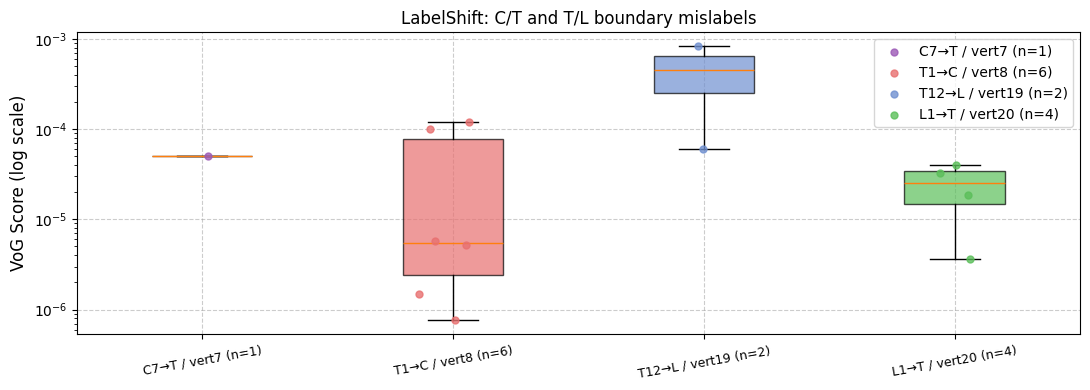

In [7]:
# LabelShift: C/T and T/L boundary mislabels
groups = [
    ("label_shift_C_as_T", 7,  "C7→T / vert7",  "#9B59B6"),
    ("label_shift_T_as_C", 8,  "T1→C / vert8",  "#E87070"),
    ("label_shift_TL",     19, "T12→L / vert19", "#7090D0"),
    ("label_shift_TL",     20, "L1→T / vert20",  "#5BBF5A"),
]

positions  = list(range(1, len(groups) + 1))
all_data   = []
all_labels = []
all_colors = []

for atype, vert, label_str, color in groups:
    ids = set(df_rc[(df_rc["anomaly_type"] == atype) & (df_rc["vert_id"] == vert)]["sample_id"].astype(str))
    sub = scores_df[scores_df["id"].isin(ids)]
    all_data.append(sub["vog_score"].values)
    all_labels.append(f"{label_str} (n={len(sub)})")
    all_colors.append(color)

fig, ax = plt.subplots(figsize=(11, 4))
bp = ax.boxplot(all_data, positions=positions, widths=0.4, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], all_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

rng = np.random.default_rng(42)
for pos, vals, color, label in zip(positions, all_data, all_colors, all_labels):
    ax.scatter(rng.normal(pos, 0.07, size=len(vals)), vals,
               color=color, alpha=0.8, s=25, zorder=3, label=label)

ax.set_yscale("log")
ax.set_ylabel("VoG Score (log scale)", fontsize=12)
ax.set_title("LabelShift: C/T and T/L boundary mislabels", fontsize=12)
ax.set_xticks(positions)
ax.set_xticklabels(all_labels, fontsize=9, rotation=10)
ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_facecolor("white")
ax.legend(fontsize=10, frameon=True)
plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/boxplot_LabelShift_vog.pdf", dpi=300, bbox_inches="tight")
plt.show()

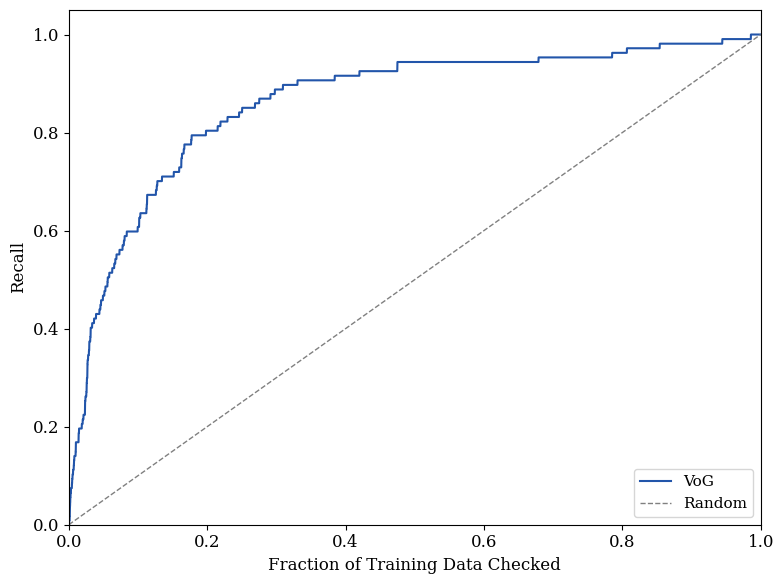

Fraction checked → Recall (VoG)
  1% → 15.0%
  5% → 46.7%
  10% → 60.7%
  20% → 80.4%
  50% → 94.4%


In [8]:
# Rank-based Recall Curve
def recall_curve(df, score_col, ascending=False):
    sorted_df = df.dropna(subset=[score_col]).sort_values(score_col, ascending=ascending).reset_index(drop=True)
    n         = len(sorted_df)
    n_pos     = int(sorted_df["mislabeled"].sum())
    fracs     = np.arange(1, n + 1) / n
    recalls   = sorted_df["mislabeled"].cumsum().values / n_pos
    return fracs, recalls

fracs_vog, rec_vog = recall_curve(scores_df, "vog_score", ascending=False)

plt.rcParams.update({"font.family": "serif", "font.size": 12})

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fracs_vog, rec_vog, color="#2255AA", linewidth=1.5, label="VoG")
ax.plot([0, 1], [0, 1], color="gray", linewidth=1, linestyle="--", label="Random")

ax.set_xlabel("Fraction of Training Data Checked", fontsize=12)
ax.set_ylabel("Recall", fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11, frameon=True, loc="lower right")
ax.set_facecolor("white")
ax.grid(False)
plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/recall_curve_vog.jpg", dpi=300, bbox_inches="tight")
plt.show()

print("Fraction checked → Recall (VoG)")
for frac in [0.01, 0.05, 0.10, 0.20, 0.50]:
    i = min(int(np.searchsorted(fracs_vog, frac, side="right")) - 1, len(fracs_vog) - 1)
    print(f"  {frac:.0%} → {rec_vog[i]:.1%}")

/tmp/ipykernel_3414542/2520735860.py:12: RuntimeWarning: invalid value encountered in divide
  f1        = np.where(denom > 0, 2 * precision * recall / denom, 0.0)


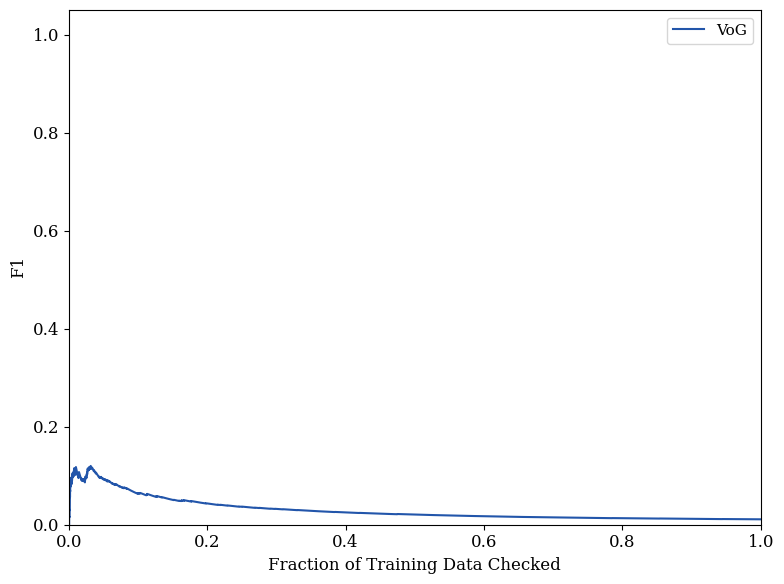

Fraction checked → F1 (VoG)
  1% → 0.107
  5% → 0.093
  10% → 0.064
  20% → 0.043
  50% → 0.021


In [9]:
# Rank-based F1 Curve
def f1_curve(df, score_col, ascending=False):
    sorted_df = df.dropna(subset=[score_col]).sort_values(score_col, ascending=ascending).reset_index(drop=True)
    n         = len(sorted_df)
    n_pos     = int(sorted_df["mislabeled"].sum())
    fracs     = np.arange(1, n + 1) / n
    cum_found = sorted_df["mislabeled"].cumsum().values
    k         = np.arange(1, n + 1)
    precision = cum_found / k
    recall    = cum_found / n_pos
    denom     = precision + recall
    f1        = np.where(denom > 0, 2 * precision * recall / denom, 0.0)
    return fracs, f1

fracs_vog_f1, f1_vog = f1_curve(scores_df, "vog_score", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fracs_vog_f1, f1_vog, color="#2255AA", linewidth=1.5, label="VoG")

ax.set_xlabel("Fraction of Training Data Checked", fontsize=12)
ax.set_ylabel("F1", fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11, frameon=True, loc="upper right")
ax.set_facecolor("white")
ax.grid(False)
plt.tight_layout()
plt.savefig("/home/student/lisa_ma/figures/f1_curve_vog.jpg", dpi=300, bbox_inches="tight")
plt.show()

print("Fraction checked → F1 (VoG)")
for frac in [0.01, 0.05, 0.10, 0.20, 0.50]:
    i = min(int(np.searchsorted(fracs_vog_f1, frac, side="right")) - 1, len(fracs_vog_f1) - 1)
    print(f"  {frac:.0%} → {f1_vog[i]:.3f}")